# Cannabis Strain Type Prediction

This project predicts cannabis strain type from effect and flavor features. I start with a binary Indica/Sativa problem, then extend the workflow to multiclass prediction with Hybrid strains included so I can see how much harder the classification becomes when the overlapping Hybrid category is added.

## Overview

The goal is to compare linear and nonlinear classifiers and understand which strain categories are easiest or hardest to separate.

In [2]:
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression

## Indica and Sativa Are the Most Distinct Strain Types

I first limited the data to Sativa and Indica strains because these two classes are more distinct than Hybrid strains.

In [3]:
df = pd.read_csv('cannabis_full.csv')

df['Type'] = df['Type'].str.strip().str.lower()

df_cleaned = df[df['Type'].isin(['sativa', 'indica'])].copy()

df_cleaned['Type'] = df_cleaned['Type'].map({'indica': 0, 'sativa': 1}).astype(int)

df_cleaned.head()

,Strain,Type,Rating,Effects,Flavor,Creative,Energetic,Tingly,Euphoric,Relaxed,...,Ammonia,Minty,Tree,Fruit,Butter,Pineapple,Tar,Rose,Plum,Pear
2,1024,1,4.4,"Uplifted,Happy,Relaxed,Energetic,Creative","Spicy/Herbal,Sage,Woody",1.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,3-Bears-Og,0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,303-Og,0,4.2,"Relaxed,Happy,Euphoric,Uplifted,Giggly","Citrus,Pungent,Earthy",0.0,0.0,0.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,3D-Cbd,1,4.6,"Uplifted,Focused,Happy,Talkative,Relaxed","Earthy,Woody,Flowery",0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,3X-Crazy,0,4.4,"Relaxed,Tingly,Happy,Euphoric,Uplifted","Earthy,Grape,Sweet",0.0,0.0,1.0,1.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## RBF SVC Has the Highest Binary Accuracy at 0.860

I compared LDA, QDA, RBF SVC, and polynomial SVM using cross-validated accuracy.

In [4]:
X = df_cleaned.drop(columns=['Type'])
y = df_cleaned['Type']

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, stratify=y)

### LDA Reaches 0.843 Accuracy as a Linear Baseline

I chose LDA as the linear baseline because it is simple, interpretable, and does not require much hyperparameter tuning.

In [5]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.model_selection import cross_val_score

lda = LinearDiscriminantAnalysis()

lda_df = df_cleaned.drop(columns=['Strain', 'Effects', 'Flavor'])
lda_df_clean = lda_df.dropna()

X = lda_df_clean.drop(columns=['Type'])
y = lda_df_clean['Type']

y = y.astype(int)
cv_scores = cross_val_score(lda, X, y, cv=5, scoring='accuracy')

print(f"The LDA Cross Validated Mean Accuracy Score is: {cv_scores.mean()} from received Accuracy scores of:{cv_scores}")

The LDA Cross Validated Mean Accuracy Score is: 0.8425808776425369 from received Accuracy scores of:[0.84821429 0.84821429 0.82589286 0.84753363 0.84304933]


LDA performs well for a simple linear model, with mean cross-validated accuracy of about 0.843.

In [6]:
lda.fit(X, y)

,"solver solver: {'svd', 'lsqr', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'lsqr': Least squares solution. Can be combined with shrinkage or custom covariance estimator. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator... versionchanged:: 1.2 `solver=""svd""` now has experimental Array API support. See the :ref:`Array API User Guide ` for more details.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter.This should be left to None if `covariance_estimator` is used.Note that shrinkage works only with 'lsqr' and 'eigen' solvers.For a usage example, see:ref:`sphx_glr_auto_examples_classification_plot_lda.py`.",None
,"priors priors: array-like of shape (n_classes,), default=NoneThe class prior probabilities. By default, the class proportions areinferred from the training data.",None
,"n_components n_components: int, default=NoneNumber of components (<= min(n_classes - 1, n_features)) fordimensionality reduction. If None, will be set tomin(n_classes - 1, n_features). This parameter only affects the`transform` method.For a usage example, see:ref:`sphx_glr_auto_examples_decomposition_plot_pca_vs_lda.py`.",None
,"store_covariance store_covariance: bool, default=FalseIf True, explicitly compute the weighted within-class covariancematrix when solver is 'svd'. The matrix is always computedand stored for the other solvers... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for a singular value of X to be consideredsignificant, used to estimate the rank of X. Dimensions whosesingular values are non-significant are discarded. Only used ifsolver is 'svd'... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimatethe covariance matrices instead of relying on the empiricalcovariance estimator (with potential shrinkage).The object should have a fit method and a ``covariance_`` attributelike the estimators in :mod:`sklearn.covariance`.if None the shrinkage parameter drives the estimate.This should be left to None if `shrinkage` is used.Note that `covariance_estimator` works only with 'lsqr' and 'eigen'solvers... versionadded:: 0.24",None


The LDA confusion matrix correctly classifies 627 Indica strains and 345 Sativa strains, with more Sativa errors than Indica errors.

In [7]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


y_pred = lda.predict(X)

cm = confusion_matrix(y, y_pred)

lda_cm = pd.DataFrame(cm)
lda_cm

,0,1
0,627,60
1,86,345


### QDA Improves Binary Accuracy to 0.854 With Regularization

I chose QDA because it allows a more flexible class boundary than LDA. I tuned `reg_param` because the effect and flavor dummy features are sparse and correlated, which can make QDA covariance estimates unstable.

In [8]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.model_selection import GridSearchCV
import warnings
warnings.filterwarnings("ignore")


qda = QuadraticDiscriminantAnalysis()

param_grid = {'reg_param': [0, 0.001, 0.01, 0.05, 0.1, 0.2, 0.5]}

qda_grid = GridSearchCV(qda, param_grid, cv=5, scoring='accuracy')
qda_grid.fit(X, y)

qda_best = qda_grid.best_estimator_
qda_best_score = qda_grid.best_score_

print(f"The QDA Cross Validated Mean Accuracy Score is: {qda_best_score} and the best regularization score is: {qda_grid.best_params_['reg_param']}")

The QDA Cross Validated Mean Accuracy Score is: 0.8542240550928891 and the best regularization score is: 0.1


With `reg_param = 0.1`, QDA reaches a mean cross-validated accuracy of about 0.854, which is slightly higher than LDA.

In [9]:
qda_best.fit(X, y)

,"solver solver: {'svd', 'eigen'}, default='svd'Solver to use, possible values: - 'svd': Singular value decomposition (default). Does not compute the covariance matrix, therefore this solver is recommended for data with a large number of features. - 'eigen': Eigenvalue decomposition. Can be combined with shrinkage or custom covariance estimator.",'svd'
,"shrinkage shrinkage: 'auto' or float, default=NoneShrinkage parameter, possible values: - None: no shrinkage (default). - 'auto': automatic shrinkage using the Ledoit-Wolf lemma. - float between 0 and 1: fixed shrinkage parameter. Enabling shrinkage is expected to improve the model when some classes have a relatively small number of training data points compared to the number of features by mitigating overfitting during the covariance estimation step.This should be left to `None` if `covariance_estimator` is used.Note that shrinkage works only with 'eigen' solver.",None
,"priors priors: array-like of shape (n_classes,), default=NoneClass priors. By default, the class proportions are inferred from thetraining data.",None
,"reg_param reg_param: float, default=0.0Regularizes the per-class covariance estimates by transforming S2 as``S2 = (1 - reg_param) * S2 + reg_param * np.eye(n_features)``,where S2 corresponds to the `scaling_` attribute of a given class.",0.1
,"store_covariance store_covariance: bool, default=FalseIf True, the class covariance matrices are explicitly computed andstored in the `self.covariance_` attribute... versionadded:: 0.17",False
,"tol tol: float, default=1.0e-4Absolute threshold for the covariance matrix to be considered rankdeficient after applying some regularization (see `reg_param`) to each`Sk` where `Sk` represents covariance matrix for k-th class. Thisparameter does not affect the predictions. It controls when a warningis raised if the covariance matrix is not full rank... versionadded:: 0.17",0.0001
,"covariance_estimator covariance_estimator: covariance estimator, default=NoneIf not None, `covariance_estimator` is used to estimate the covariancematrices instead of relying on the empirical covariance estimator(with potential shrinkage). The object should have a fit method anda ``covariance_`` attribute like the estimators in:mod:`sklearn.covariance`. If None the shrinkage parameter drives theestimate.This should be left to `None` if `shrinkage` is used.Note that `covariance_estimator` works only with the 'eigen' solver.",None


The QDA confusion matrix improves Sativa classification compared with LDA, increasing correct Sativa predictions from 345 to 368.

In [10]:
y_pred_qda = qda_best.predict(X)

cm_qda = confusion_matrix(y, y_pred_qda)

qda_cm = pd.DataFrame(cm_qda)
qda_cm

,0,1
0,624,63
1,63,368


### RBF SVC Performs Best With 0.860 Binary Accuracy

I chose an RBF SVC because it can learn nonlinear decision boundaries. I tuned `C` and `gamma` because `C` controls the penalty for classification errors and `gamma` controls how curved the decision boundary can become.

In [11]:
from sklearn.svm import SVC

svc = SVC()

param_grid = {'C': [0.1, 1, 5, 10, 20], 'gamma': ['scale', 0.01, 0.05, 0.1, 0.2], 'kernel': ['rbf']}

svc_grid = GridSearchCV(svc, param_grid, cv=5, scoring='accuracy')
svc_grid.fit(X, y)

svc_best = svc_grid.best_estimator_
svc_best_score = svc_grid.best_score_

print(f"The Best SVC Cross-Validated Accuracy Score is: {svc_best_score} and the best hyperparameters are: {svc_grid.best_params_}")

The Best SVC Cross-Validated Accuracy Score is: 0.860482062780269 and the best hyperparameters are: {'C': 1, 'gamma': 0.2, 'kernel': 'rbf'}


The RBF SVC has the highest binary cross-validated accuracy at about 0.860, using `C = 1` and `gamma = 0.2`.

In [12]:
svc_best.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.2
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


The SVC confusion matrix shows the cleanest binary split, with fewer Indica and Sativa errors than the other fitted binary models. This supports choosing the RBF SVC as the strongest Indica/Sativa classifier.

In [13]:
y_pred_svc = svc_best.predict(X)

cm_svc = confusion_matrix(y, y_pred_svc)

svc_cm = pd.DataFrame(cm_svc)

svc_cm

,0,1
0,658,29
1,45,386


### Polynomial SVM Reaches 0.854 but Does Not Beat RBF SVC

I also tested a polynomial SVM as another nonlinear option. I tuned `C`, `degree`, and `gamma` because these control the error penalty, polynomial complexity, and kernel scale.

In [14]:
svm_poly = SVC(kernel='poly')

param_grid = {'C': [0.1, 1, 5, 10], 'degree': [2, 3, 4],'gamma': ['scale', 0.01, 0.05, 0.1]}

svm_poly_grid = GridSearchCV(svm_poly, param_grid, cv=5, scoring='accuracy')
svm_poly_grid.fit(X, y)

svm_poly_best = svm_poly_grid.best_estimator_
svm_poly_best_score = svm_poly_grid.best_score_

print(f"Best Polynomial SVM Accuracy: {svm_poly_best_score} and the best hyperparameters are:", svm_poly_grid.best_params_)

Best Polynomial SVM Accuracy: 0.8542040358744394 and the best hyperparameters are: {'C': 1, 'degree': 2, 'gamma': 0.05}


The best polynomial SVM has degree 2 and cross-validated accuracy of about 0.854, which is close to QDA but still below the RBF SVC.

In [15]:
svm_poly_best.fit(X, y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'poly'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",2
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",0.05
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


The polynomial SVM improves over the linear baseline but does not outperform the RBF SVC. I would choose the RBF SVC for the binary task because it has the best accuracy at about 0.860 and the cleanest confusion matrix.

In [16]:
y_pred_svm_poly = svm_poly_best.predict(X)

cm_svm_poly = confusion_matrix(y, y_pred_svm_poly)

svm_poly_cm = pd.DataFrame(cm_svm_poly)

svm_poly_cm

,0,1
0,640,47
1,89,342


## Adding Hybrid Strains Drops Accuracy From 0.860 to About 0.629

Next, I included Hybrid strains and treated the task as a three-class classification problem. Accuracy drops because Hybrid strains share characteristics with both Sativa and Indica.

In [17]:
df['Type'] = df['Type'].astype(str).str.strip().str.lower()

df_full = df[df['Type'].isin(['sativa','indica','hybrid'])].copy()

df_full = df_full.drop(columns=['Strain', 'Effects', 'Flavor'])

df_full['type_class'] = df_full['Type'].map({'indica': 0, 'sativa': 1, 'hybrid': 2}).astype(int)

X_full = df_full.drop(columns=['Type','type_class'])
y_full = df_full['type_class']

## Decision Tree Shows Hybrid Strains Fall Between Indica and Sativa

I fit a decision tree to give a visual set of classification rules for the effect and flavor features. Each final node represents the most common strain type for strains with that combination of feature values.

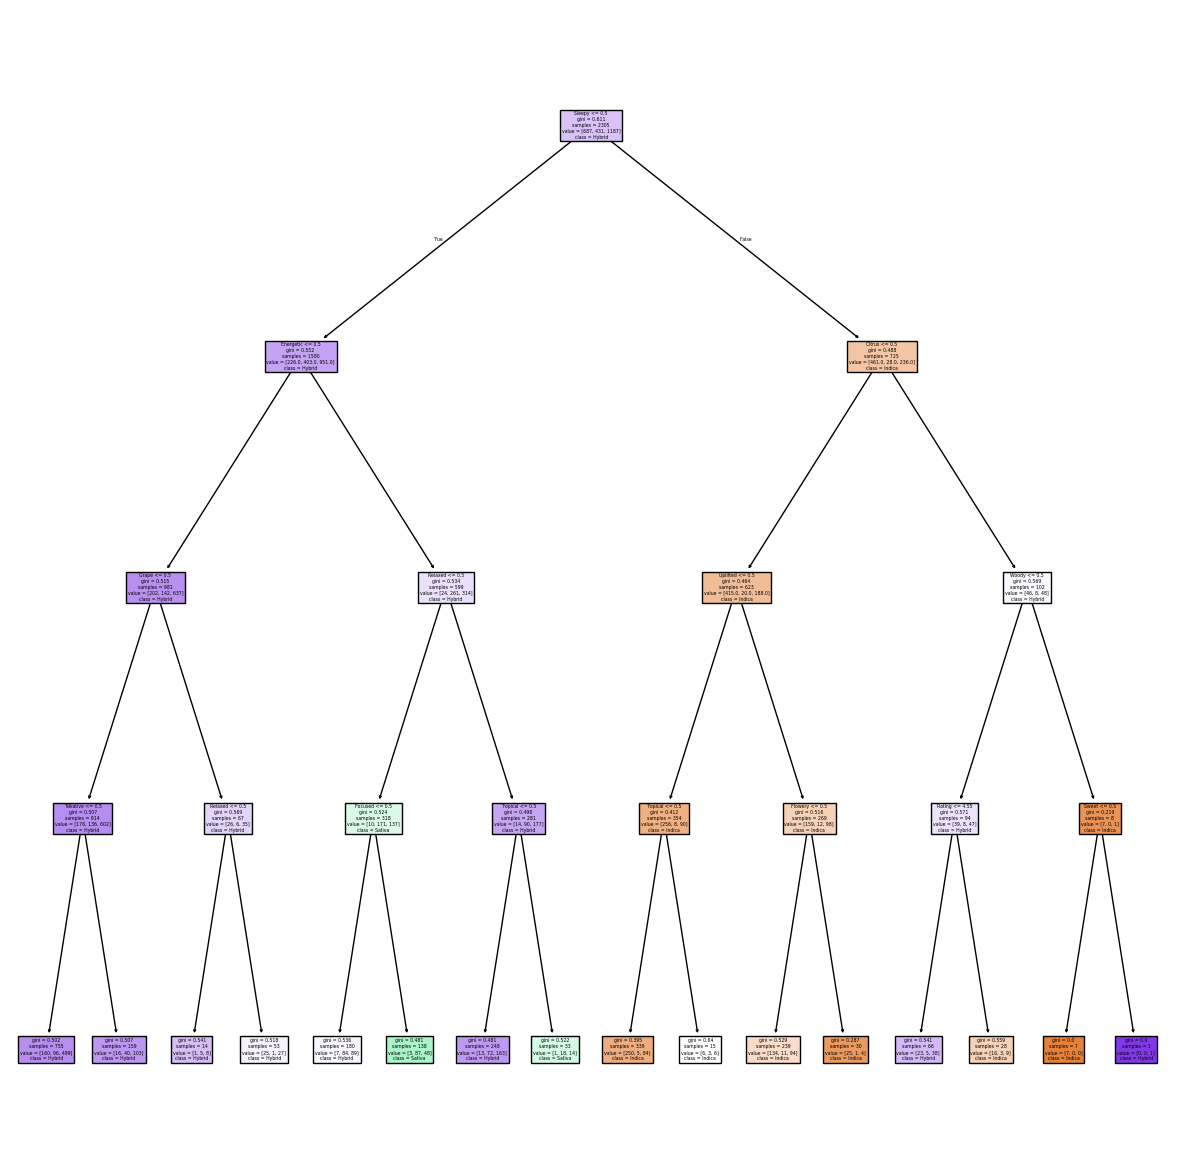

In [18]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

X_full_model = X_full.dropna()
y_full_model = y_full.loc[X_full_model.index]

dt = DecisionTreeClassifier(max_depth=4, random_state=1)
dt.fit(X_full_model, y_full_model)

plt.figure(figsize=(15, 15))
plot_tree(dt, filled=True, feature_names=X_full.columns, class_names=['Indica', 'Sativa', 'Hybrid'])
plt.show()

The decision tree shows Indica strains clustering around relaxing or sedating effects, while Sativa strains are more associated with energizing or uplifting effects. Hybrid strains fall between the two, which explains why the three-class problem is harder.

## Multiclass LDA Performs Best but Only Reaches 0.629 Accuracy

### LDA Performs Best Among the Three Multiclass Models

In [19]:
X_model = X_full.dropna()
y_model = y_full.loc[X_model.index]

lda_full = LinearDiscriminantAnalysis()
lda_full_cv = cross_val_score(lda_full, X_model, y_model, cv=5, scoring='accuracy')

print("LDA CV Accuracy:", lda_full_cv.mean())
print("LDA Fold Scores:", lda_full_cv)

lda_full.fit(X_model, y_model)

lda_pred = lda_full.predict(X_model)

lda_cm_full = pd.DataFrame(confusion_matrix(y_model, lda_pred), index=['Actual Indica','Actual Sativa','Actual Hybrid'], columns=['Pred Indica','Pred Sativa','Pred Hybrid'])

lda_cm_full

LDA CV Accuracy: 0.6290672451193059
LDA Fold Scores: [0.61388286 0.62689805 0.61822126 0.64859002 0.63774403]


,Pred Indica,Pred Sativa,Pred Hybrid
Actual Indica,467,9,211
Actual Sativa,21,186,224
Actual Hybrid,211,147,829


### QDA Drops to 0.596 Accuracy in the Three-Class Model

I kept `reg_param=0.1` from the binary QDA tuning because the three-class setup uses the same collinear dummy-feature structure.

In [20]:
qda_full = QuadraticDiscriminantAnalysis(reg_param=0.1)
qda_full_cv = cross_val_score(qda_full, X_model, y_model, cv=5, scoring='accuracy')

print("QDA CV Accuracy:", qda_full_cv.mean())
print("QDA Fold Scores:", qda_full_cv)

qda_full.fit(X_model, y_model)

qda_pred = qda_full.predict(X_model)

qda_cm_full = pd.DataFrame(confusion_matrix(y_model, qda_pred), index=['Actual Indica','Actual Sativa','Actual Hybrid'], columns=['Pred Indica','Pred Sativa','Pred Hybrid'])

qda_cm_full

QDA CV Accuracy: 0.5960954446854664
QDA Fold Scores: [0.56832972 0.61388286 0.60737527 0.56616052 0.62472885]


,Pred Indica,Pred Sativa,Pred Hybrid
Actual Indica,536,13,138
Actual Sativa,22,253,156
Actual Hybrid,282,141,764


### KNN Performs Slightly Better Than QDA at 0.600 Accuracy

I used KNN as a distance-based multiclass comparison. It performs slightly better than QDA, but it still falls below LDA.

In [21]:
param_grid_knn = {'n_neighbors': [1, 3, 5, 7, 9, 11, 15]}

knn_grid = GridSearchCV(KNeighborsClassifier(), param_grid_knn, cv=5, scoring='accuracy')

knn_grid.fit(X_model, y_model)

print("Best KNN CV Accuracy:", knn_grid.best_score_)
print("Best k:", knn_grid.best_params_)

knn_best = knn_grid.best_estimator_
knn_best.fit(X_model, y_model)

knn_pred = knn_best.predict(X_model)

knn_cm_full = pd.DataFrame(confusion_matrix(y_model, knn_pred), index=['Actual Indica','Actual Sativa','Actual Hybrid'], columns=['Pred Indica','Pred Sativa','Pred Hybrid'])

knn_cm_full

Best KNN CV Accuracy: 0.6004338394793927
Best k: {'n_neighbors': 15}


,Pred Indica,Pred Sativa,Pred Hybrid
Actual Indica,440,6,241
Actual Sativa,25,148,258
Actual Hybrid,188,77,922


The multiclass models perform worse than the binary models because Hybrid strains overlap with both Sativa and Indica. LDA performs best among these three multiclass models with cross-validated accuracy of about 0.629, followed by KNN at about 0.600 and QDA at about 0.596.

The confusion matrices show that Hybrid creates most of the classification difficulty. Many actual Indica and Sativa strains are predicted as Hybrid, while Indica and Sativa are rarely confused directly with each other.

## Sativa Is Easiest to Separate, While Hybrid Is Hardest

I broke the multiclass problem into binary tasks to identify which strain categories are easiest and hardest to separate. For one-vs-rest, each model compares one strain type against the other two combined. For one-vs-one, each model compares two strain types directly.

### One-vs-Rest: Indica Is Easier Than Hybrid but Harder Than Sativa

Indica vs. Not Indica performs in the middle of the one-vs-rest results, with logistic regression at about 0.793 and SVC at about 0.787.

In [22]:
y_indica = (y_model == 0).astype(int)
y_sativa = (y_model == 1).astype(int)
y_hybrid = (y_model == 2).astype(int)

svc_indica = SVC().fit(X_model, y_indica)
log_indica = LogisticRegression(max_iter=500).fit(X_model, y_indica)
svc_indica_score = cross_val_score(SVC(), X_model, y_indica, cv=5, scoring='accuracy').mean()
log_indica_score = cross_val_score(LogisticRegression(max_iter=500), X_model, y_indica, cv=5, scoring='accuracy').mean()

### One-vs-Rest: Sativa Is the Easiest Class to Separate

Sativa vs. Not Sativa has the strongest one-vs-rest result, especially with logistic regression at about 0.828 accuracy.

In [23]:
svc_sativa_score = cross_val_score(SVC(), X_model, y_sativa, cv=5, scoring='accuracy').mean()
log_sativa_score = cross_val_score(LogisticRegression(max_iter=500), X_model, y_sativa, cv=5, scoring='accuracy').mean()

### One-vs-Rest: Hybrid Is the Hardest Class to Separate

Hybrid vs. Not Hybrid has the weakest one-vs-rest result, with both models near 0.62 accuracy.

In [24]:
svc_hybrid_score = cross_val_score(SVC(), X_model, y_hybrid, cv=5, scoring='accuracy').mean()
log_hybrid_score = cross_val_score(LogisticRegression(max_iter=500), X_model, y_hybrid, cv=5, scoring='accuracy').mean()

In [25]:
ovr_scores = pd.DataFrame({'Target Class': ['Indica', 'Indica', 'Sativa', 'Sativa', 'Hybrid', 'Hybrid'], 'Model Type': ['SVC', 'Logistic', 'SVC', 'Logistic', 'SVC', 'Logistic'], 'Accuracy': [svc_indica_score,log_indica_score, svc_sativa_score, log_sativa_score, svc_hybrid_score, log_hybrid_score]})

ovr_scores

,Target Class,Model Type,Accuracy
0,Indica,SVC,0.786985
1,Indica,Logistic,0.793059
2,Sativa,SVC,0.813015
3,Sativa,Logistic,0.828200
4,Hybrid,SVC,0.625597
5,Hybrid,Logistic,0.616920


In the one-vs-rest setup, Sativa vs. Not Sativa performs best. Logistic regression has the highest Sativa accuracy at about 0.828, while SVC reaches about 0.813. Indica vs. Not Indica is slightly lower, with accuracy around 0.787 for SVC and 0.793 for logistic regression. Hybrid vs. Not Hybrid performs worst, with accuracy around 0.626 for SVC and 0.617 for logistic regression. This pattern reflects the overlap between Hybrid strains and the other two classes.

In [26]:
X_01 = X_model[(y_model==0)|(y_model==1)]
y_01 = y_model[(y_model==0)|(y_model==1)]

X_02 = X_model[(y_model==0)|(y_model==2)]
y_02 = y_model[(y_model==0)|(y_model==2)]

X_12 = X_model[(y_model==1)|(y_model==2)]
y_12 = y_model[(y_model==1)|(y_model==2)]

### One-vs-One: Indica and Sativa Are the Clearest Pair

Indica vs. Sativa is the strongest pairwise comparison, reaching about 0.851 accuracy with SVC.

In [27]:
svc_01 = cross_val_score(SVC(), X_01, y_01, cv=5, scoring='accuracy').mean()
log_01 = cross_val_score(LogisticRegression(max_iter=500), X_01, y_01, cv=5, scoring='accuracy').mean()

### One-vs-One: Indica and Hybrid Have More Overlap

Indica vs. Hybrid is harder than Indica vs. Sativa because Hybrid strains share some Indica-like effects.

In [28]:
svc_02 = cross_val_score(SVC(), X_02, y_02, cv=5, scoring='accuracy').mean()
log_02 = cross_val_score(LogisticRegression(max_iter=500), X_02, y_02, cv=5, scoring='accuracy').mean()

### One-vs-One: Sativa and Hybrid Are Also Difficult to Separate

Sativa vs. Hybrid also shows overlap, with SVC dropping to about 0.731 accuracy.

In [29]:
svc_12 = cross_val_score(SVC(), X_12, y_12, cv=5, scoring='accuracy').mean()
log_12 = cross_val_score(LogisticRegression(max_iter=500), X_12, y_12, cv=5, scoring='accuracy').mean()

In [30]:
ovo_scores = pd.DataFrame({'Model': ['SVC', 'Logistic'], 'Indica vs Sativa': [svc_01, log_01], 'Indica vs Hybrid': [svc_02, log_02], 'Hybrid vs Sativa': [svc_12, log_12]})

ovo_scores

,Model,Indica vs Sativa,Indica vs Hybrid,Hybrid vs Sativa
0,SVC,0.850649,0.752408,0.731153
1,Logistic,0.845263,0.753484,0.752165


The Indica vs. Sativa classifiers perform best because those two classes are the most distinct. SVC reaches about 0.851 accuracy and logistic regression reaches about 0.845 for that pair. Comparisons involving Hybrid are harder: Indica vs. Hybrid is about 0.752 to 0.753, and Hybrid vs. Sativa is about 0.731 for SVC and 0.752 for logistic regression. This matches the one-vs-rest results: Hybrid is the category that creates most of the classification difficulty.

## Logistic Regression Uses One-vs-Rest While SVC Uses One-vs-One

If the full dataset is passed directly into `LogisticRegression`, scikit-learn uses a one-vs-rest style strategy by default for this kind of multiclass setup. For `SVC`, scikit-learn uses one-vs-one internally.

This matches how the models work: logistic regression compares one class against the rest, while SVC compares pairs of classes internally.